# Fitting a bimodal PDF to the density diagnostic trend

This is an extension of the `density_diagnostic_trends` and `density_diagnostic_fit` notebooks, with the aim to repeat the analysis for a bimodal density distribution.

This is at the behest of Referees #1+#2


In [1]:
import numpy as np
from astropy.table import Table
from matplotlib import pyplot as plt
import seaborn as sns
import corner
from lmfit import Model
import ddtrends as ddt
from orion_diagnostics import ori_tab

## Observational data

Grab the Eduardo data for Orion diagnostics versus n_M

In [2]:
subset = ori_tab["independent?"]
xdata = ori_tab[subset]["log10(n_M)"].data
ydata = ori_tab[subset]["log10(n_obs)"].data
xdata, ydata

(array([3.06, 3.16, 3.74, 3.84, 3.99, 4.85, 5.03, 6.19, 6.31]),
 array([2.309, 2.54 , 2.685, 2.395, 3.07 , 2.757, 2.942, 3.696, 3.333]))

##  Bimodal density PDF

Define a model in log-log space for the bimodal distribution. 

In [3]:
def bimodal_model(x, f, log_n0, log_width):
    """
    Model function for log10_n_obs(log10_n_M) with parameters (f, log_n0, log_width)

    The high density component is log_n1 = log_n0 + log_width, with emission fraction f

    We do not use log_n1 directly as a parameter since we want to make sure
    it is always greater than the lower bound. Also, it is very poorly constrained by the data

    Suitable for use with lmfit.Model
    """

    # Set up diagnostic line ratio parameters
    nM = 10 ** x
    # Vary with nM = 1e3 -> 1e7 as delta = 2 -> 200
    delta = 2.0 * np.sqrt(nM / 1e3)

    # Set up power-law PDF
    log_n1 = log_n0 + log_width
    pdf = ddt.BimodalPDF(f, 10 ** log_n0, 10 ** log_n1)

    # Find observed density using the vectorized function
    n_obs = ddt.n_app_from_nM(nM, pdf, delta=delta)

    return np.log10(n_obs)
    

bmodel = Model(bimodal_model)

Use similar broad priors for the parameters. For the high density fraction, we allow any $0 < f < 1$

In [4]:
params = bmodel.make_params(
    f=dict(value=0.05, min=0.0, max=1.0),
    log_n0=dict(value=-1.0, min=-3, max=3.5),
    # log_width=dict(value=5.0, min=0.1, max=12),
    log_width=dict(value=5.0, min=0.1, max=8),
)
params

name,value,initial value,min,max,vary
f,0.05000000,0.05,0.00000000,1.00000000,True
log_n0,-1.00000000,-1.0,-3.00000000,3.50000000,True
log_width,5.00000000,5.0,0.10000000,8.00000000,True


Set uniform weights and do the fit

In [5]:
sig_y = 0.25 * np.ones_like(ydata)

## Perform the initial fit with Levenberg-Marquardt

In [6]:
result = bmodel.fit(ydata, params, x=xdata, weights=1 / sig_y)

In [7]:
from IPython.display import Markdown, display

def show_fit_md(result, heading="Fit result", level=4):
    hashes = "#" * level
    report = result.fit_report()
    display(Markdown(f"{hashes} {heading}\n\n```text\n{report}\n```"))



In [8]:
show_fit_md(result, heading="LMfit result", level=3)

### LMfit result

```text
[[Model]]
    Model(bimodal_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 66
    # data points      = 9
    # variables        = 3
    chi-square         = 7.05457750
    reduced chi-square = 1.17576292
    Akaike info crit   = 3.80806907
    Bayesian info crit = 4.39974280
    R-squared          = 0.73064101
[[Variables]]
    f:          0.11957983 +/- 0.05220540 (43.66%) (init = 0.05)
    log_n0:     2.58854202 +/- 0.12529385 (4.84%) (init = -1)
    log_width:  3.58668573 +/- 0.98587925 (27.49%) (init = 5)
[[Correlations]] (unreported correlations are < 0.100)
    C(f, log_width)      = +0.4232
    C(log_n0, log_width) = +0.2170
```

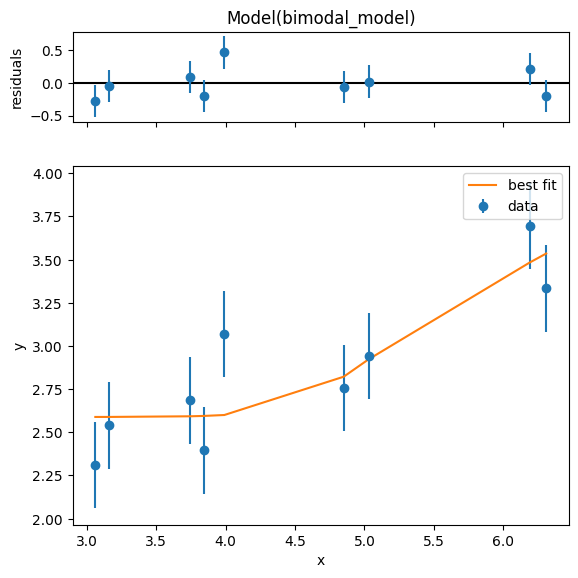

In [10]:
result.plot();

## Sample posterior with MCMC

In [11]:
mcmc_params = result.params.copy()

In [21]:
emcee_kws = dict(
    steps=30_000,
    burn=1000,
    thin=10,
    seed=2026_09_07,
    progress=True,
    workers=1,
)

In [22]:
mcmc_result = bmodel.fit(
    data=ydata,
    x=xdata,
    weights=1 / sig_y,
    params=mcmc_params,
    method="emcee",
    fit_kws=emcee_kws,
) 

100%|██████████| 30000/30000 [01:23<00:00, 357.28it/s]


In [23]:
show_fit_md(mcmc_result, heading="MCMC result", level=3)

### MCMC result

```text
[[Model]]
    Model(bimodal_model)
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 3000000
    # data points      = 9
    # variables        = 3
    chi-square         = 12.7548566
    reduced chi-square = 2.12580943
    Akaike info crit   = 9.13818775
    Bayesian info crit = 9.72986149
    R-squared          = 0.51299206
[[Variables]]
    f:          0.23273886 +/- 0.18993280 (81.61%) (init = 0.1195798)
    log_n0:     2.46309741 +/- 1.03791407 (42.14%) (init = 2.588542)
    log_width:  3.27406100 +/- 1.84835318 (56.45%) (init = 3.586686)
[[Correlations]] (unreported correlations are < 0.100)
    C(f, log_width)      = +0.4789
    C(f, log_n0)         = -0.4785
    C(log_n0, log_width) = -0.2376
```

### Compare LMfit versus MCMC

In [24]:
result.params

name,value,standard error,relative error,initial value,min,max,vary
f,0.11957983,0.05220540,(43.66%),0.05,0.00000000,1.00000000,True
log_n0,2.58854202,0.12529385,(4.84%),-1.0,-3.00000000,3.50000000,True
log_width,3.58668573,0.98587925,(27.49%),5.0,0.10000000,8.00000000,True


In [25]:
mcmc_result.params

name,value,standard error,relative error,initial value,min,max,vary
f,0.23273886,0.18993280,(81.61%),0.11957982988960059,0.00000000,1.00000000,True
log_n0,2.46309741,1.03791407,(42.14%),2.5885420235858714,-3.00000000,3.50000000,True
log_width,3.27406100,1.84835318,(56.45%),3.5866857262486977,0.10000000,8.00000000,True


In [26]:
fc = mcmc_result.flatchain
print("quantile", *mcmc_result.var_names)
for q in [0.05, 0.16, 0.50, 0.84, 0.95]:
    print(q, *[f"{fc[p].quantile(q):.2f}" for p in mcmc_result.var_names] )

quantile f log_n0 log_width
0.05 0.09 -1.85 1.64
0.16 0.12 0.63 1.96
0.5 0.23 2.46 3.27
0.84 0.50 2.67 5.65
0.95 0.65 2.76 6.61


### Plot the posterior samples

In [29]:
posterior_samples = mcmc_result.flatchain.sample(n=100, random_state=1943_09_25)

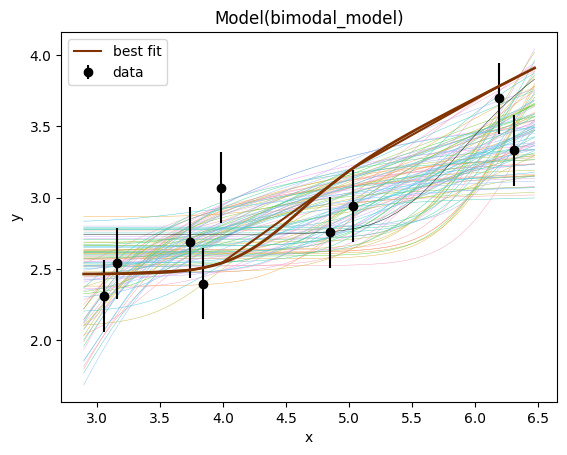

In [30]:
# Pastel colored lines for the posterior sample
my_palette = sns.husl_palette(n_colors=101, s=0.9, l=0.75, h=0.8)
# Reserve first two colormap entries for data and best fit, with darker colors
my_palette[0] = (0, 0, 0)
my_palette[1] = (0.5, 0.2, 0)
with my_palette:
    g = mcmc_result.plot_fit()
    xx = np.linspace(*g.get_xlim())
    for d in posterior_samples.to_dict(orient="records"):
        g.plot(xx, mcmc_result.eval(x=xx, **d), alpha=1, lw=0.3, zorder=-1)
    # Replot the fit line over the full range, making sure to use the same color
    g.plot(xx, mcmc_result.eval(x=xx), lw=2, color=sns.color_palette()[1])

## Corner plot of MCMC result for bimodal distro

In [36]:
red_cmap = sns.color_palette("light:#c6a", n_colors=4)
red_cmap[0] = (1, 1, 1)
red_cmap

[(1, 1, 1),
 (0.8986958938539525, 0.7612915321244713, 0.8524410548732823),
 (0.8493479469269762, 0.5806457660622357, 0.7595538607699744),
 (0.8, 0.4, 0.6666666666666666)]

In [38]:
samples = mcmc_result.flatchain[["f", "log_n0", "log_width"]]
samples["log_n1"] = samples["log_n0"] + samples["log_width"]
samples

,f,log_n0,log_width,log_n1
0,0.198473,2.454702,1.819510,4.274212
1,0.240941,2.502799,1.302425,3.805224
2,0.221078,2.306800,1.884840,4.191641
3,0.568061,-2.687761,5.838530,3.150769
4,0.371741,2.137791,1.524021,3.661812
...,...,...,...,...
289995,0.425774,2.647001,6.305763,8.952764
289996,0.228338,2.511081,4.586952,7.098033
289997,0.796183,2.744081,7.364460,10.108542
289998,0.083940,2.540734,2.601166,5.141900


### Uninformative prior

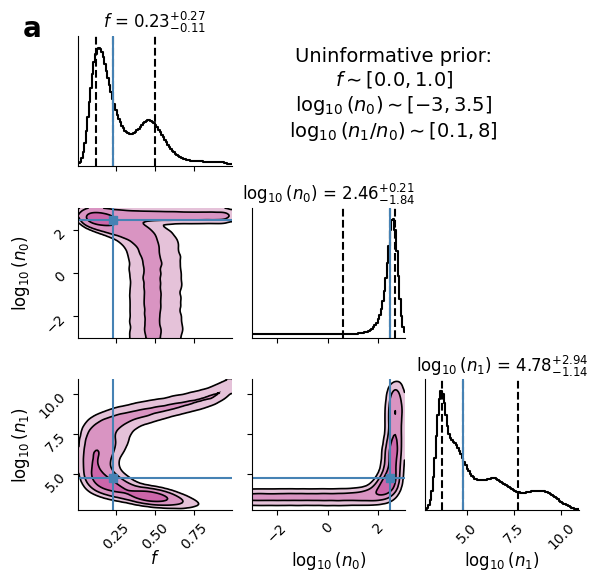

In [63]:
labels = [
    r"$f$",
    r"$\log_{10} (n_0)$",
    r"$\log_{10} (n_1)$",
]
fig = corner.corner(
    samples[["f", "log_n0", "log_n1"]],
    labels=labels,
    truths=[
        np.median(samples["f"]),
        np.median(samples["log_n0"]),
        np.median(samples["log_n1"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 12},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": red_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.text(
    4/6, 
    5/6, 
    (
        "Uninformative prior:\n" 
        r"$f \sim [0.0, 1.0]$" "\n"
        r"$\log_{10} (n_0) \sim [-3, 3.5]$" "\n"
        r"$\log_{10} (n_1 / n_0) \sim [0.1, 8]$" 
    ),
    ha="center",
    va="center",
    fontsize=14,
)
fig.text(0.08, 0.92, "a", ha="right", va="bottom", fontsize=20, fontweight="bold")
fig.set_size_inches(6.0, 6.0)
fig.tight_layout()
fig.savefig("bimodal-density-distribution-mcmc-corner-uniform.pdf")

### Informative prior on bimodal model, constrained by RMS density

We define a bimodal density model with 3-parameters: $n_0$ is the density of the low-density phase, $n_1$ is the density of the high-density phase, and $f$ is the fraction of the emission-measure that comes from the high-density phase. The density PDF is therefore:
$$
H_n = (1 - f)\, \delta(n - n_0) + f\, \delta(n - n_1),
$$
where $\delta(\cdots)$ is the Dirac delta function (not the same as $\delta$ parameter in the two-level atom model). 

According to my handwritten notes, the RMS density is given by
$$
n_\mathrm{rms} = 
\left[
\frac{1 + f / (1 - f)}{1 + (n_0^2 / n_1^2) f / (1 - f)}
\right]^{1/2}
n_0
$$
It is interesting that if $n_1 \gg n_0$, then the RMS density becomes insensitive to the value of $n_1$. Physically, this is because if the emission fraction $f$ is constant, then the volume of the dense phase is inversely proportional to its density-squared, so its contribution to the RMS is fixed. 

In [48]:
class BimodalPDF:
    """
    Bimodal density PDF
    """

    def __init__(self, frac: float, n0: float, n1: float):
        """
        Parameters: low density `n0`, high density `n1`, fraction of emission from high density `frac`
        """
        self.frac = frac
        self.n0 = n0
        self.n1 = n1
        self.label = rf"$n_0 = {n0:.2g}$, $n_1 = {n1:.2g}$, $f = {frac:.2g}$"

    def nrms(self):
        """
        Calculate the RMS density of a bimodal distribution

        This is always volume-weighted
        """
        ff = self.frac / (1 - self.frac)
        n0_n1 = self.n0 / self.n1
        n2mean = self.n0**2 * (1 + ff) / (1 + n0_n1**2 * ff)
        # Cast to a normal float
        return float(np.sqrt(n2mean))


In [49]:
samples["log_nrms"] = samples.apply(
    lambda x: np.log10(
        ddt.BimodalPDF(x["f"], 10 ** x["log_n0"], 10 ** x["log_n1"]).nrms()
    ),
    axis=1,
)

In [50]:
samples

,f,log_n0,log_width,log_n1,log_nrms
0,0.198473,2.454702,1.819510,4.274212,2.502731
1,0.240941,2.502799,1.302425,3.805224,2.562490
2,0.221078,2.306800,1.884840,4.191641,2.361043
3,0.568061,-2.687761,5.838530,3.150769,-2.505472
4,0.371741,2.137791,1.524021,3.661812,2.238607
...,...,...,...,...,...
289995,0.425774,2.647001,6.305763,8.952764,2.767459
289996,0.228338,2.511081,4.586952,7.098033,2.567368
289997,0.796183,2.744081,7.364460,10.108542,3.089461
289998,0.083940,2.540734,2.601166,5.141900,2.559772


In [54]:
# arrays from the existing flattened chain

f = samples["f"]
log_nmin = samples["log_n0"].to_numpy()
log_nmax = samples["log_n1"].to_numpy()
log_nrms = samples["log_nrms"].to_numpy()  # derived quantity already computed

# proposed prior on log10(n_rms)
mu = 2.3
sigma = 0.45
# Evaluate log of weights for a Gaussian PDF 
# ignoring constant subtractive terms since we normalize later after exponentiating
logw = -0.5 * ((log_nrms - mu) / sigma)**2

# stabilize and normalize
logw -= np.nanmax(logw)
w = np.exp(logw)
w /= np.sum(w)

# effective sample size
neff = 1.0 / np.sum(w**2)
print(f"N_eff = {neff:.0f} out of {len(w)}")

N_eff = 217368 out of 290000


In [60]:
def weighted_quantile(x, q, w):
    idx = np.argsort(x)
    xs = x[idx]
    ws = w[idx]
    cdf = np.cumsum(ws)
    return np.interp(q, cdf, xs)

for q in [0.0228, 0.1587, 0.5, 0.8413, 0.9772]:
    print(q, weighted_quantile(log_nrms, q, w))

0.0228 1.8645912669290656
0.1587 2.2723641970411372
0.5 2.530402961746564
0.8413 2.7105109153812177
0.9772 2.900590295633992


In [71]:
new_cmap = sns.color_palette("light:#8c5", n_colors=4)
new_cmap[0] = (1, 1, 1)
new_cmap

[(1, 1, 1),
 (0.7958653900847628, 0.9006185715844848, 0.7220871212231939),
 (0.6645993617090481, 0.8503092857922424, 0.5277102272782637),
 (0.5333333333333333, 0.8, 0.3333333333333333)]

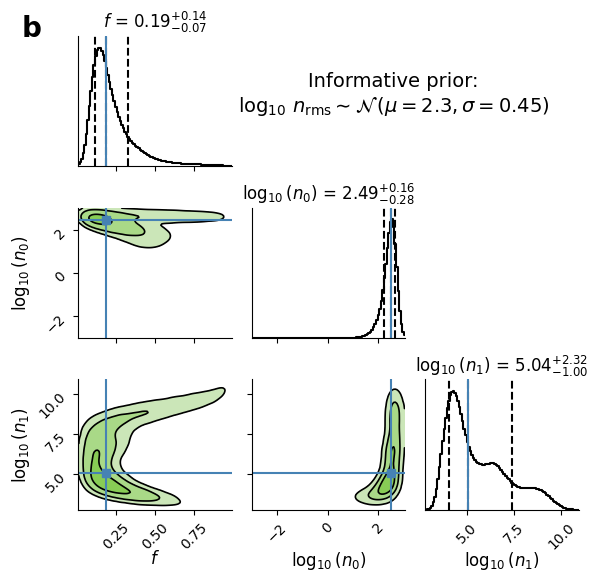

In [72]:
labels = [
    r"$f$",
    r"$\log_{10} (n_0)$",
    r"$\log_{10} (n_1)$",
]
fig = corner.corner(
    samples[["f", "log_n0", "log_n1"]],
    weights=w,
    labels=labels,
    truths=[
        weighted_quantile(samples["f"], 0.5, w),
        weighted_quantile(samples["log_n0"], 0.5, w),
        weighted_quantile(samples["log_n1"], 0.5, w),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 12},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": new_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.text(
    4/6, 
    5/6, 
    "Informative prior:\n" + r"$\log_{10}\, n_\text{rms} \sim \mathcal{N}\,(\mu = 2.3, \sigma = 0.45)$",
    ha="center",
    va="center",
    fontsize=14,
)
fig.text(0.08, 0.92, "b", ha="right", va="bottom", fontsize=20, fontweight="bold")
fig.set_size_inches(6.0, 6.0)
fig.tight_layout()
fig.savefig("bimodal-density-distribution-mcmc-corner-informative-nrms.pdf")

## Repeat plot the posterior samples but using weights from the informative prior

In [82]:
weighted_samples = mcmc_result.flatchain.sample(n=100, weights=w, random_state=1966_09_25)

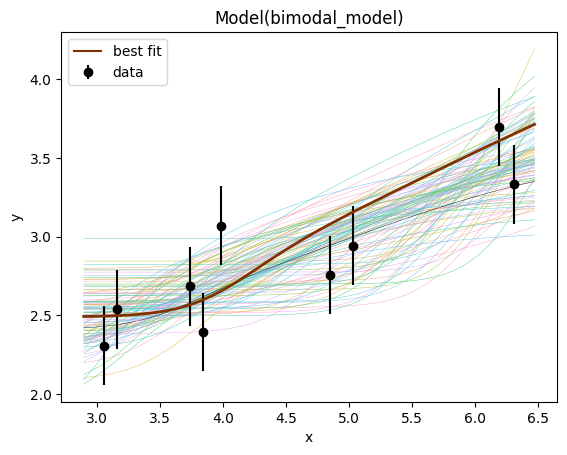

In [98]:
# Pastel colored lines for the posterior sample
my_palette = sns.husl_palette(n_colors=101, s=0.9, l=0.75, h=0.8)
# Reserve first two colormap entries for data and best fit, with darker colors
my_palette[0] = (0, 0, 0)
my_palette[1] = (0.5, 0.2, 0)
with my_palette:
    g = result.plot_fit(numpoints=100)
    g.lines[1].remove()
    xx = np.linspace(*g.get_xlim())
    for d in weighted_samples.to_dict(orient="records"):
        g.plot(xx, mcmc_result.eval(x=xx, **d), alpha=1, lw=0.3, zorder=-1)
    # Replot the fit line over the full range, making sure to use the same color
    truths = dict(
        f=weighted_quantile(samples["f"], 0.5, w),
        log_n0=weighted_quantile(samples["log_n0"], 0.5, w),
        log_width=weighted_quantile(samples["log_width"], 0.5, w),
    )
    g.plot(xx, mcmc_result.eval(x=xx, **truths), lw=2, color=sns.color_palette()[1])

In [95]:
mcmc_result.flatchain.sample?

Signature:
mcmc_result.flatchain.sample(
    n: 'int | None' = None,
    frac: 'float | None' = None,
    replace: 'bool_t' = False,
    weights=None,
    random_state: 'RandomState | None' = None,
    axis: 'Axis | None' = None,
    ignore_index: 'bool_t' = False,
) -> 'Self'
Docstring:
Return a random sample of items from an axis of object.

You can use `random_state` for reproducibility.

Parameters
----------
n : int, optional
    Number of items from axis to return. Cannot be used with `frac`.
    Default = 1 if `frac` = None.
frac : float, optional
    Fraction of axis items to return. Cannot be used with `n`.
replace : bool, default False
    Allow or disallow sampling of the same row more than once.
weights : str or ndarray-like, optional
    Default 'None' results in equal probability weighting.
    If passed a Series, will align with target object on index. Index
    values in weights not found in sampled object will be ignored and
    index values in sampled object not in we

In [97]:
result.plot?

Signature:
result.plot(
    datafmt='o',
    fitfmt='-',
    initfmt='--',
    xlabel=None,
    ylabel=None,
    yerr=None,
    numpoints=None,
    fig=None,
    data_kws=None,
    fit_kws=None,
    init_kws=None,
    ax_res_kws=None,
    ax_fit_kws=None,
    fig_kws=None,
    show_init=False,
    parse_complex='abs',
    title=None,
)
Docstring:
Plot the fit results and residuals using matplotlib.

The method will produce a matplotlib figure (if package available)
with both results of the fit and the residuals plotted. If the fit
model included weights, errorbars will also be plotted. To show
the initial conditions for the fit, pass the argument
``show_init=True``.

Parameters
----------
datafmt : str, optional
    Matplotlib format string for data points.
fitfmt : str, optional
    Matplotlib format string for fitted curve.
initfmt : str, optional
    Matplotlib format string for initial conditions for the fit.
xlabel : str, optional
    Matplotlib format string for labeling the x-ax